# Cross-Model Comparison of Outlier Behaviour

Compares the three per-model outlier studies (Random Forest, MLP, XGBoost) across the same
9 conditions (3 feature sets x 3 split strategies, target = CO2 uptake at 0.1 bar).

Summary-level numbers (RMSE, outlier rates, persistence counts, descriptor-category counts) are
copied directly from the cell outputs of:
- `notebooks/prediction_outlier_analysis_rf.ipynb`
- `notebooks/prediction-outlier_analysis_mlp.ipynb`
- `notebooks/prediction-outlier_analysis.ipynb` (XGBoost)

The final section opens the per-MOF parquets (`outlier_predictions_*.parquet`) and computes
cross-model overlap of persistent outliers. It runs only if all three parquets are on disk.

In [1]:
import pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

ROOT    = pathlib.Path('..').resolve()
RESULTS = ROOT / 'results' / 'model-comparison-outliers'
RESULTS.mkdir(parents=True, exist_ok=True)

MODELS      = ['rf', 'mlp', 'xgb']
MODEL_LABEL = {'rf': 'Random Forest', 'mlp': 'MLP', 'xgb': 'XGBoost'}
MODEL_COLOR = {'rf': '#2ca25f', 'mlp': '#3182bd', 'xgb': '#e6550d'}
FEAT_SETS   = ['geo_all', 'rac_all', 'combined_all']
SPLITS_LIST = ['random', 'topology', 'metal']
CONDITIONS  = [f'{sp}__{fs}' for sp in SPLITS_LIST for fs in FEAT_SETS]

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Output dir:', RESULTS)

Output dir: /Users/hannah/Desktop/ethz/Semester6/dc-mof-project/results/model-comparison-outliers


## Summary statistics from the three per-model notebooks

These tables are transcribed from the printed outputs of each notebook. If a notebook is rerun
and the numbers change, update the dictionaries below.

In [2]:
# RMSE per condition for each model.  Order: condition = '{split}__{feature_set}'.
RMSE = {
    'rf': {
        'random__geo_all':       0.3740, 'random__rac_all':       0.6095, 'random__combined_all':   0.3151,
        'topology__geo_all':     0.3244, 'topology__rac_all':     0.5895, 'topology__combined_all': 0.3515,
        'metal__geo_all':        0.3800, 'metal__rac_all':        0.6550, 'metal__combined_all':    0.3508,
    },
    'mlp': {
        'random__geo_all':       0.3731, 'random__rac_all':       0.6157, 'random__combined_all':   0.3140,
        'topology__geo_all':     0.3362, 'topology__rac_all':     0.6296, 'topology__combined_all': 0.3454,
        'metal__geo_all':        0.3709, 'metal__rac_all':        0.6384, 'metal__combined_all':    0.3680,
    },
    'xgb': {
        'random__geo_all':       0.3736, 'random__rac_all':       0.6088, 'random__combined_all':   0.3064,
        'topology__geo_all':     0.3280, 'topology__rac_all':     0.5749, 'topology__combined_all': 0.3658,
        'metal__geo_all':        0.3733, 'metal__rac_all':        0.6518, 'metal__combined_all':    0.3437,
    },
}
rmse_df = pd.DataFrame(RMSE).reindex(CONDITIONS)
rmse_df.columns = [MODEL_LABEL[m] for m in rmse_df.columns]
print('RMSE per condition (mol/kg):')
rmse_df.round(4)

RMSE per condition (mol/kg):


,Random Forest,MLP,XGBoost
random__geo_all,0.3740,0.3731,0.3736
random__rac_all,0.6095,0.6157,0.6088
random__combined_all,0.3151,0.3140,0.3064
topology__geo_all,0.3244,0.3362,0.3280
topology__rac_all,0.5895,0.6296,0.5749
topology__combined_all,0.3515,0.3454,0.3658
metal__geo_all,0.3800,0.3709,0.3733
metal__rac_all,0.6550,0.6384,0.6518
metal__combined_all,0.3508,0.3680,0.3437


In [3]:
# Outlier rate per condition (%), threshold = 2 * std(abs_error) per condition.
OUTLIER_PCT = {
    'rf': {
        'random__geo_all':        8.9, 'random__rac_all':        9.1, 'random__combined_all':    8.4,
        'topology__geo_all':     16.7, 'topology__rac_all':     10.0, 'topology__combined_all': 10.0,
        'metal__geo_all':        10.5, 'metal__rac_all':         9.0, 'metal__combined_all':    10.0,
    },
    'mlp': {
        'random__geo_all':        8.6, 'random__rac_all':        9.2, 'random__combined_all':    8.9,
        'topology__geo_all':     10.0, 'topology__rac_all':     13.3, 'topology__combined_all': 13.3,
        'metal__geo_all':        10.6, 'metal__rac_all':         8.4, 'metal__combined_all':     8.6,
    },
    'xgb': {
        'random__geo_all':        8.9, 'random__rac_all':        9.0, 'random__combined_all':    9.3,
        'topology__geo_all':     13.3, 'topology__rac_all':      6.7, 'topology__combined_all': 11.7,
        'metal__geo_all':        10.6, 'metal__rac_all':         9.1, 'metal__combined_all':     9.7,
    },
}
outlier_df = pd.DataFrame(OUTLIER_PCT).reindex(CONDITIONS)
outlier_df.columns = [MODEL_LABEL[m] for m in outlier_df.columns]
print('Outlier rate per condition (% of test set flagged):')
outlier_df.round(1)

Outlier rate per condition (% of test set flagged):


,Random Forest,MLP,XGBoost
random__geo_all,8.9,8.6,8.9
random__rac_all,9.1,9.2,9.0
random__combined_all,8.4,8.9,9.3
topology__geo_all,16.7,10.0,13.3
topology__rac_all,10.0,13.3,6.7
topology__combined_all,10.0,13.3,11.7
metal__geo_all,10.5,10.6,10.6
metal__rac_all,9.0,8.4,9.1
metal__combined_all,10.0,8.6,9.7


In [4]:
# Persistence summary: how many unique MOFs are flagged across the 9 conditions.
# 'always' = outlier in ALL 9 conditions; 'majority' = outlier in >50% of conditions; 'any' = >=1.
PERSISTENCE = {
    'rf':  {'always': 1092, 'majority': 2956, 'any': 6756, 'total_mofs': 37422,
             'persistent_ge_0_5': 3027},
    'mlp': {'always':  920, 'majority': 2893, 'any': 6485, 'total_mofs': 37422,
             'persistent_ge_0_5': 2982},
    'xgb': {'always': 1112, 'majority': 2920, 'any': 6840, 'total_mofs': 37422,
             'persistent_ge_0_5': 3008},
}
persist_df = pd.DataFrame(PERSISTENCE).T
persist_df.index = [MODEL_LABEL[m] for m in persist_df.index]
print('Persistence counts (number of unique MOFs):')
persist_df

Persistence counts (number of unique MOFs):


,always,majority,any,total_mofs,persistent_ge_0_5
Random Forest,1092,2956,6756,37422,3027
MLP,920,2893,6485,37422,2982
XGBoost,1112,2920,6840,37422,3008


In [5]:
# Descriptor-type categorisation, counted on 'outlier in any split' per feature set.
# Categories from each notebook's 'descriptor-cat' cell output.
DESCRIPTOR = {
    'rf':  {'Geo only (RAC fixes)': 1401, 'RAC only (geo fixes)': 1860,
             'Always outlier (all 3)': 1138, 'Combined only': 808},
    'mlp': {'Geo only (RAC fixes)': 1843, 'RAC only (geo fixes)': 1675,
             'Always outlier (all 3)':  967, 'Combined only': 737},
    'xgb': {'Geo only (RAC fixes)': 1508, 'RAC only (geo fixes)': 1809,
             'Always outlier (all 3)': 1166, 'Combined only': 882},
}
descriptor_df = pd.DataFrame(DESCRIPTOR)
descriptor_df.columns = [MODEL_LABEL[m] for m in descriptor_df.columns]
print('Descriptor-type categorisation (MOFs flagged in any split, by feature set membership):')
descriptor_df

Descriptor-type categorisation (MOFs flagged in any split, by feature set membership):


,Random Forest,MLP,XGBoost
Geo only (RAC fixes),1401,1843,1508
RAC only (geo fixes),1860,1675,1809
Always outlier (all 3),1138,967,1166
Combined only,808,737,882


## RMSE comparison across the 9 conditions

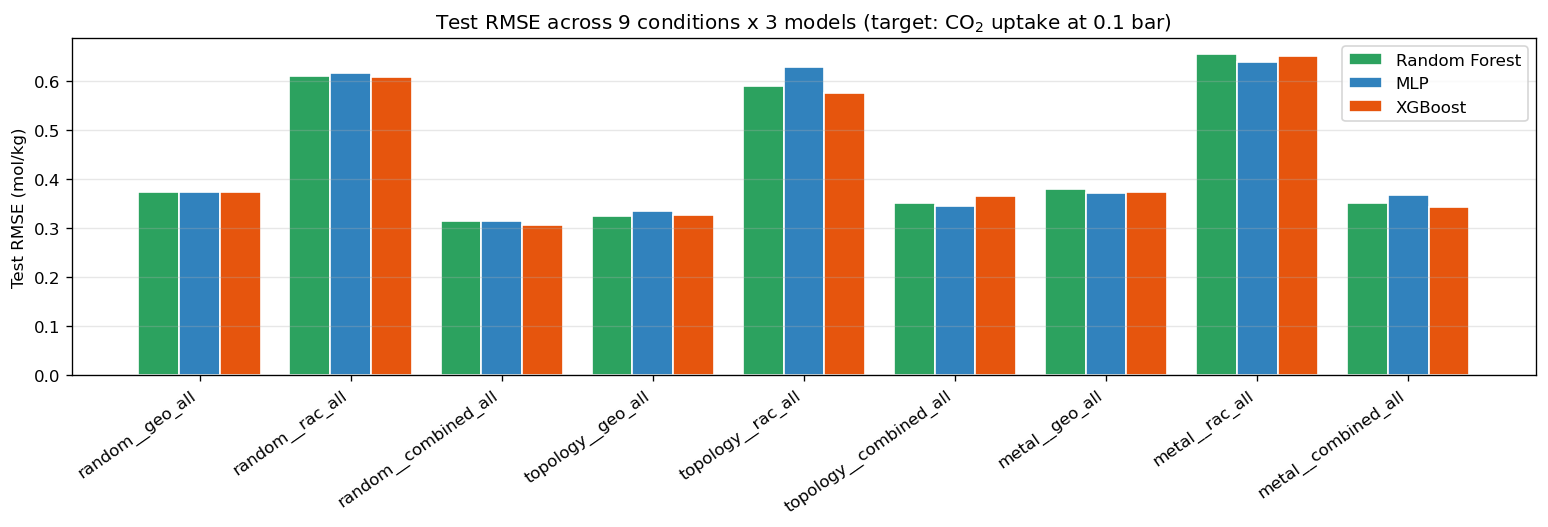

In [6]:
fig, ax = plt.subplots(figsize=(13, 4.5))
x = np.arange(len(CONDITIONS))
w = 0.27
for i, m in enumerate(MODELS):
    vals = [RMSE[m][c] for c in CONDITIONS]
    ax.bar(x + (i - 1) * w, vals, width=w,
           color=MODEL_COLOR[m], edgecolor='white', label=MODEL_LABEL[m])
ax.set_xticks(x)
ax.set_xticklabels(CONDITIONS, rotation=35, ha='right')
ax.set_ylabel('Test RMSE (mol/kg)')
ax.set_title('Test RMSE across 9 conditions x 3 models (target: CO$_2$ uptake at 0.1 bar)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'rmse_comparison.png', bbox_inches='tight')
plt.show()

In [7]:
# Per-feature-set means (averaged across splits) and per-split means (averaged across feature sets).
rows = []
for m in MODELS:
    for fs in FEAT_SETS:
        vals = [RMSE[m][f'{sp}__{fs}'] for sp in SPLITS_LIST]
        rows.append({'model': MODEL_LABEL[m], 'group': f'feature_set={fs}',
                     'mean_RMSE': np.mean(vals)})
    for sp in SPLITS_LIST:
        vals = [RMSE[m][f'{sp}__{fs}'] for fs in FEAT_SETS]
        rows.append({'model': MODEL_LABEL[m], 'group': f'split={sp}',
                     'mean_RMSE': np.mean(vals)})
marginals = pd.DataFrame(rows).pivot(index='group', columns='model', values='mean_RMSE')
print('Mean RMSE marginals (averaging the other axis):')
marginals.round(4)

Mean RMSE marginals (averaging the other axis):


model,MLP,Random Forest,XGBoost
group,,,
feature_set=combined_all,0.3425,0.3391,0.3386
feature_set=geo_all,0.3601,0.3595,0.3583
feature_set=rac_all,0.6279,0.6180,0.6118
split=metal,0.4591,0.4619,0.4563
split=random,0.4343,0.4329,0.4296
split=topology,0.4371,0.4218,0.4229


## Outlier-rate comparison across the 9 conditions

Note: outlier rates of ~8-10% are expected by construction (2 sigma threshold on per-condition error).
What matters here is relative comparison and the spikes on out-of-distribution splits (topology / metal).

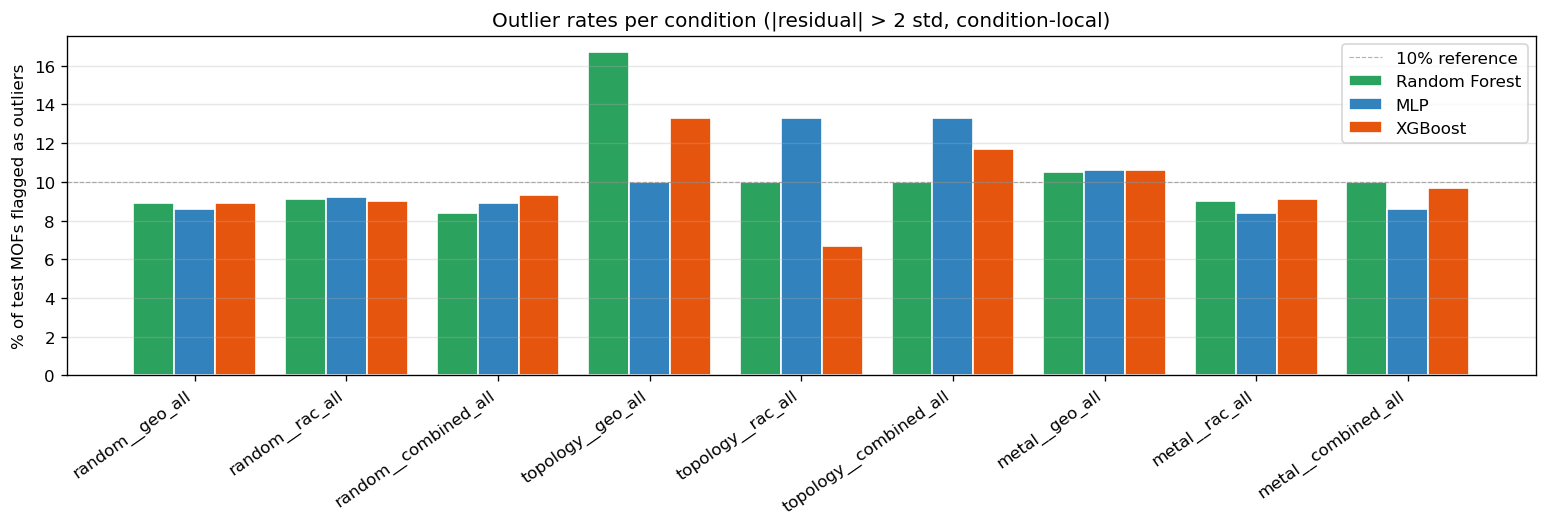

In [8]:
fig, ax = plt.subplots(figsize=(13, 4.5))
x = np.arange(len(CONDITIONS))
w = 0.27
for i, m in enumerate(MODELS):
    vals = [OUTLIER_PCT[m][c] for c in CONDITIONS]
    ax.bar(x + (i - 1) * w, vals, width=w,
           color=MODEL_COLOR[m], edgecolor='white', label=MODEL_LABEL[m])
ax.axhline(10.0, color='gray', linestyle='--', lw=0.7, alpha=0.6,
           label='10% reference')
ax.set_xticks(x)
ax.set_xticklabels(CONDITIONS, rotation=35, ha='right')
ax.set_ylabel('% of test MOFs flagged as outliers')
ax.set_title('Outlier rates per condition (|residual| > 2 std, condition-local)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_rate_comparison.png', bbox_inches='tight')
plt.show()

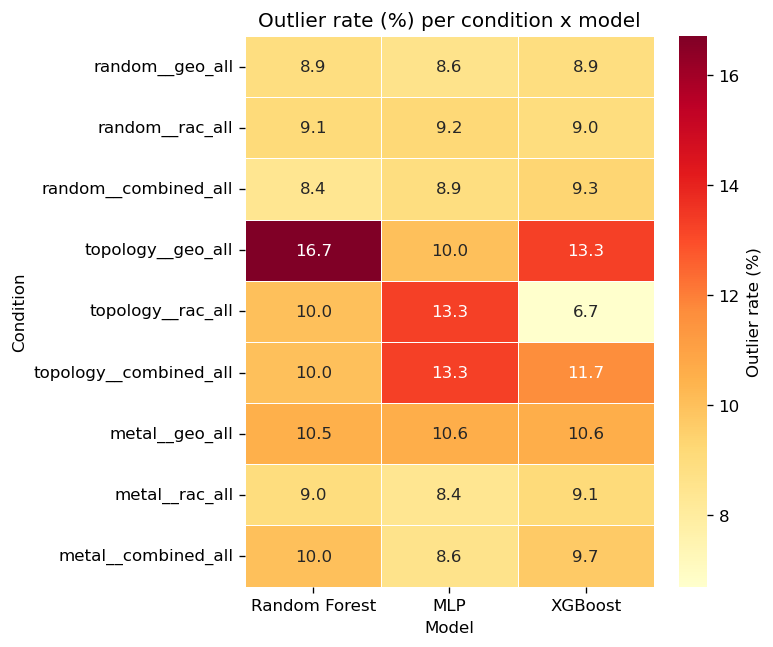

In [9]:
# Same data as a heatmap (easier to spot which split/feature combos are hardest per model).
heat_data = outlier_df.copy()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.4,
            cbar_kws={'label': 'Outlier rate (%)'}, ax=ax)
ax.set_title('Outlier rate (%) per condition x model')
ax.set_xlabel('Model')
ax.set_ylabel('Condition')
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_rate_heatmap.png', bbox_inches='tight')
plt.show()

## Persistence comparison

Persistence = fraction of the 9 conditions in which a given MOF is flagged as an outlier.
Larger 'always outlier' counts means the model has more MOFs that fail regardless of features/split.

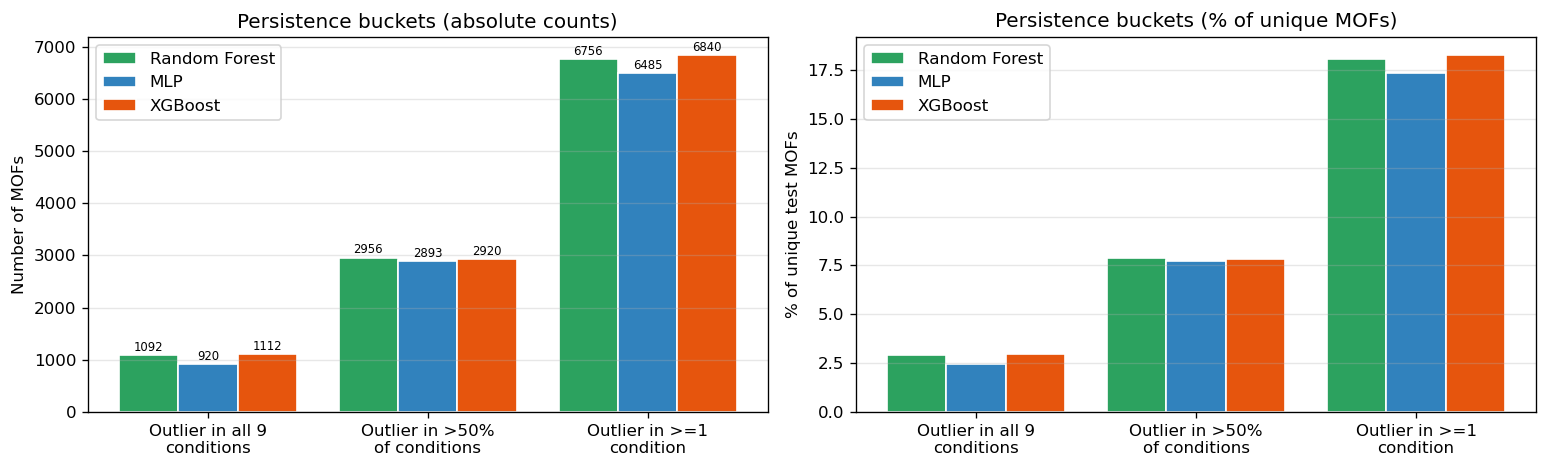

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: persistence buckets (absolute counts)
buckets = ['always', 'majority', 'any']
bucket_labels = ['Outlier in all 9\nconditions', 'Outlier in >50%\nof conditions',
                 'Outlier in >=1\ncondition']
x = np.arange(len(buckets)); w = 0.27
for i, m in enumerate(MODELS):
    vals = [PERSISTENCE[m][b] for b in buckets]
    bars = axes[0].bar(x + (i - 1) * w, vals, width=w,
                       color=MODEL_COLOR[m], edgecolor='white', label=MODEL_LABEL[m])
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                     str(v), ha='center', fontsize=7)
axes[0].set_xticks(x); axes[0].set_xticklabels(bucket_labels)
axes[0].set_ylabel('Number of MOFs')
axes[0].set_title('Persistence buckets (absolute counts)')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Right: as fraction of total test-set MOFs
for i, m in enumerate(MODELS):
    vals = [PERSISTENCE[m][b] / PERSISTENCE[m]['total_mofs'] * 100 for b in buckets]
    axes[1].bar(x + (i - 1) * w, vals, width=w,
                color=MODEL_COLOR[m], edgecolor='white', label=MODEL_LABEL[m])
axes[1].set_xticks(x); axes[1].set_xticklabels(bucket_labels)
axes[1].set_ylabel('% of unique test MOFs')
axes[1].set_title('Persistence buckets (% of unique MOFs)')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / 'persistence_comparison.png', bbox_inches='tight')
plt.show()

## Descriptor-type categorisation comparison

Each MOF is bucketed by **which feature set exposes it as an outlier**:
- **Geo only**: outlier under `geo_all` but not under `combined_all` (RAC features fix it).
- **RAC only**: outlier under `rac_all` but not under `combined_all` (geometry fixes it).
- **Always outlier (all 3)**: outlier across all three feature sets - model-agnostic failure.
- **Combined only**: outlier only under `combined_all` (rare; suggests overfitting on the merge).

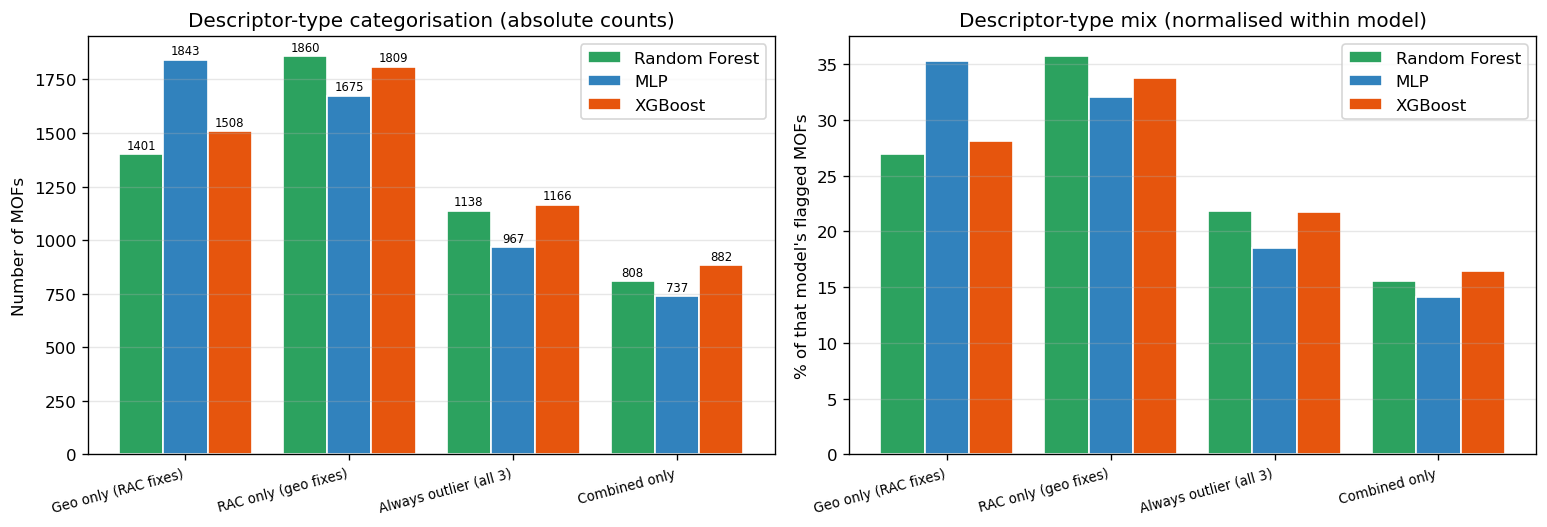

In [11]:
cats = ['Geo only (RAC fixes)', 'RAC only (geo fixes)',
        'Always outlier (all 3)', 'Combined only']
x = np.arange(len(cats)); w = 0.27

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for i, m in enumerate(MODELS):
    vals = [DESCRIPTOR[m][c] for c in cats]
    bars = axes[0].bar(x + (i - 1) * w, vals, width=w,
                       color=MODEL_COLOR[m], edgecolor='white', label=MODEL_LABEL[m])
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 25,
                     str(v), ha='center', fontsize=7)
axes[0].set_xticks(x); axes[0].set_xticklabels(cats, rotation=15, ha='right', fontsize=8)
axes[0].set_ylabel('Number of MOFs')
axes[0].set_title('Descriptor-type categorisation (absolute counts)')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Normalised view: each model's outliers as a fraction of that model's total outliers
for i, m in enumerate(MODELS):
    total = sum(DESCRIPTOR[m].values())
    vals = [DESCRIPTOR[m][c] / total * 100 for c in cats]
    axes[1].bar(x + (i - 1) * w, vals, width=w,
                color=MODEL_COLOR[m], edgecolor='white', label=MODEL_LABEL[m])
axes[1].set_xticks(x); axes[1].set_xticklabels(cats, rotation=15, ha='right', fontsize=8)
axes[1].set_ylabel('% of that model\'s flagged MOFs')
axes[1].set_title('Descriptor-type mix (normalised within model)')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / 'descriptor_category_comparison.png', bbox_inches='tight')
plt.show()

## High-level takeaways from the summary tables

- **Best accuracy on random split / combined features**: XGBoost (0.306) beats MLP (0.314) and RF (0.315), but the gap is small (~3%).
- **RAC-only models are weakest across the board** (~0.6 RMSE for all three) - confirms RAC features alone are insufficient.
- **Topology split spikes RF's geo_all outlier rate to 16.7%**, the worst single condition across the comparison - RF is the most fragile under OOD topology with geometry-only features.
- **MLP has the smallest 'always outlier' count (920) and the highest 'Geo only' count (1843)**: MLP is the most rescue-able by adding RAC features.
- **XGBoost has the largest 'always outlier' (1112) and 'Combined only' (882) counts**: it both fails on more hard cases and has more cases it 'breaks' specifically with combined features.
- **RF sits in between on persistence (1092 always-outliers)** but has the largest 'RAC only' bucket (1860) - geometry fixes those for RF more often than for the other two.

## Per-MOF cross-model overlap (requires all three prediction parquets)

Loads the per-MOF residuals saved by each per-model notebook and asks:
**which MOFs are persistent outliers in multiple models?**

Expected parquet locations:
- `results/prediction-outlier-analysis/outlier_predictions_rf.parquet`
- `results/prediction-outlier-analysis-mlp/outlier_predictions_mlp.parquet`
- `results/prediction-outlier-analysis/outlier_predictions_xgb.parquet`

If any are missing, the cells below print which ones and stop early.

In [12]:
PARQUETS = {
    'rf':  ROOT / 'results' / 'prediction-outlier-analysis'     / 'outlier_predictions_rf.parquet',
    'mlp': ROOT / 'results' / 'prediction-outlier-analysis-mlp' / 'outlier_predictions_mlp.parquet',
    'xgb': ROOT / 'results' / 'prediction-outlier-analysis'     / 'outlier_predictions_xgb.parquet',
}

available = {m: p for m, p in PARQUETS.items() if p.exists()}
missing   = {m: p for m, p in PARQUETS.items() if not p.exists()}

print('Available parquets:')
for m, p in available.items(): print(f'  {m}: {p.relative_to(ROOT)}')
if missing:
    print('\nMissing parquets (per-MOF analysis below will skip):')
    for m, p in missing.items(): print(f'  {m}: {p.relative_to(ROOT)}')
    print('\nTo populate: rerun the per-model notebook on a machine that has its joblib models,\n'
          'or copy the parquet from a teammate.')


def add_outlier_flag(df):
    """Reproduce the per-condition 2-sigma outlier flag from the per-model notebooks.

    The saved parquets are written before the flag step, so we apply the same logic here:
    threshold per `condition` = 2 * std(abs_error) within that condition.
    """
    thresholds = df.groupby('condition')['abs_error'].std().mul(2).rename('threshold')
    df = df.drop(columns=['threshold', 'is_outlier'], errors='ignore').join(thresholds, on='condition')
    df['is_outlier'] = df['abs_error'] > df['threshold']
    return df


preds_by_model = {m: add_outlier_flag(pd.read_parquet(p)) for m, p in available.items()}
for m, df in preds_by_model.items():
    rate = df.groupby('condition')['is_outlier'].mean().mul(100)
    print(f'  loaded {m}: {len(df):,} rows, {df["name"].nunique():,} unique MOFs, '
          f'{df["condition"].nunique()} conditions, outlier-rate range '
          f'{rate.min():.1f}-{rate.max():.1f}%')

Available parquets:
  rf: results/prediction-outlier-analysis/outlier_predictions_rf.parquet
  mlp: results/prediction-outlier-analysis-mlp/outlier_predictions_mlp.parquet
  xgb: results/prediction-outlier-analysis/outlier_predictions_xgb.parquet


  loaded rf: 121,323 rows, 37,422 unique MOFs, 9 conditions, outlier-rate range 8.4-16.7%
  loaded mlp: 121,323 rows, 37,422 unique MOFs, 9 conditions, outlier-rate range 8.4-13.3%
  loaded xgb: 121,323 rows, 37,422 unique MOFs, 9 conditions, outlier-rate range 6.7-13.3%


In [13]:
# Recompute persistence per model from the parquets so we can examine *which* MOFs overlap.
def persistence_for(df):
    n_seen    = df.groupby('name')['condition'].count()
    n_outlier = df[df['is_outlier']].groupby('name')['condition'].count()
    return (n_outlier / n_seen).fillna(0)

persist_by_model = {m: persistence_for(df) for m, df in preds_by_model.items()}

# Re-derive the summary numbers and check they line up with the hardcoded PERSISTENCE table.
for m, ps in persist_by_model.items():
    print(f'{m}: always={(ps == 1.0).sum()}  majority={(ps > 0.5).sum()}  any={(ps > 0).sum()}  '
          f'total={len(ps)}')

rf: always=1092  majority=2956  any=6756  total=37422
mlp: always=920  majority=2893  any=6485  total=37422
xgb: always=1112  majority=2920  any=6840  total=37422


In [14]:
# Sets of 'persistent' MOFs (persistence >= 0.5) per model, then their pairwise overlaps.
if len(persist_by_model) < 2:
    print('Need at least 2 parquets for overlap analysis - skipping.')
else:
    THRESH = 0.5
    sets = {m: set(ps[ps >= THRESH].index) for m, ps in persist_by_model.items()}

    print(f'Persistent-outlier set sizes (persistence >= {THRESH}):')
    for m, s in sets.items(): print(f'  {m}: {len(s):,}')

    print('\nPairwise overlaps (|A & B| / |A | B|, Jaccard):')
    keys = list(sets.keys())
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            a, b = sets[keys[i]], sets[keys[j]]
            inter = len(a & b); union = len(a | b)
            print(f'  {keys[i]:>3} & {keys[j]:<3}: |intersect|={inter:,}  '
                  f'|union|={union:,}  Jaccard={inter/union:.3f}')

    if len(sets) == 3:
        all3 = sets['rf'] & sets['mlp'] & sets['xgb']
        print(f'\nMOFs flagged persistent by ALL three models: {len(all3):,}')
        any_pair = (sets['rf'] & sets['mlp']) | (sets['rf'] & sets['xgb']) | (sets['mlp'] & sets['xgb'])
        print(f'MOFs flagged persistent by at least two models: {len(any_pair):,}')

Persistent-outlier set sizes (persistence >= 0.5):
  rf: 3,027
  mlp: 2,982
  xgb: 3,008

Pairwise overlaps (|A & B| / |A | B|, Jaccard):
   rf & mlp: |intersect|=2,244  |union|=3,765  Jaccard=0.596
   rf & xgb: |intersect|=2,492  |union|=3,543  Jaccard=0.703
  mlp & xgb: |intersect|=2,297  |union|=3,693  Jaccard=0.622

MOFs flagged persistent by ALL three models: 2,070
MOFs flagged persistent by at least two models: 2,893


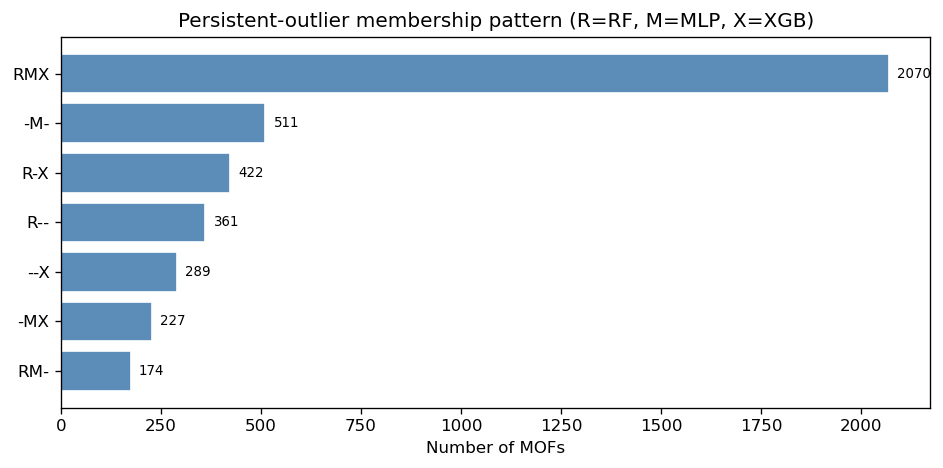

In [15]:
# Membership-pattern bar chart (UpSet-lite). Each MOF gets a 3-bit signature (RF, MLP, XGB).
if len(persist_by_model) == 3:
    THRESH = 0.5
    sets = {m: set(ps[ps >= THRESH].index) for m, ps in persist_by_model.items()}
    universe = sets['rf'] | sets['mlp'] | sets['xgb']
    rows = []
    for name in universe:
        sig = (
            'R' if name in sets['rf']  else '-',
            'M' if name in sets['mlp'] else '-',
            'X' if name in sets['xgb'] else '-',
        )
        rows.append(''.join(sig))
    pattern_counts = pd.Series(rows).value_counts().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(pattern_counts.index, pattern_counts.values, color='#5b8db8', edgecolor='white')
    for y, v in enumerate(pattern_counts.values):
        ax.text(v + max(pattern_counts.values) * 0.01, y, str(v), va='center', fontsize=8)
    ax.set_xlabel('Number of MOFs')
    ax.set_title('Persistent-outlier membership pattern (R=RF, M=MLP, X=XGB)')
    plt.tight_layout()
    plt.savefig(RESULTS / 'persistent_outlier_membership.png', bbox_inches='tight')
    plt.show()
else:
    print('Need all three parquets for the membership-pattern chart.')

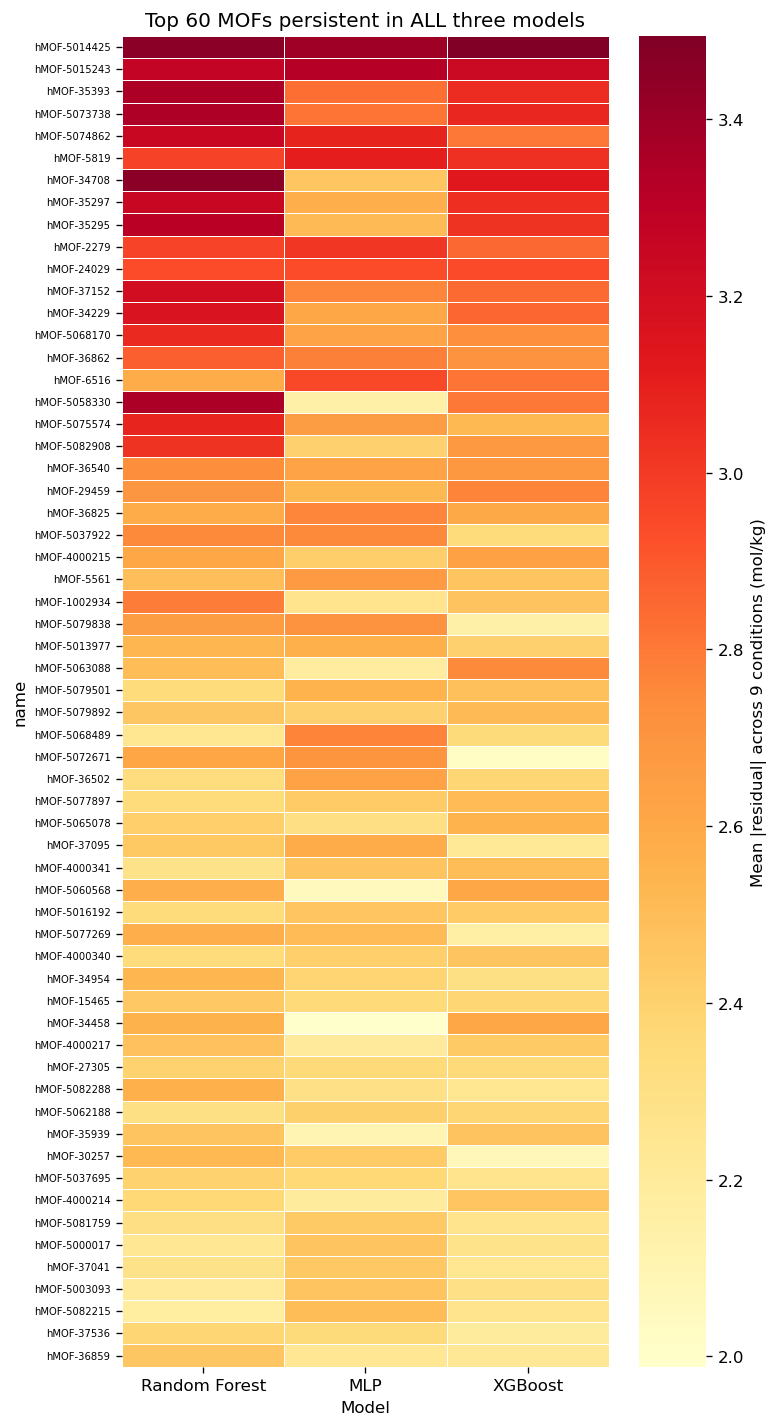

Saved full list of 2070 shared persistent outliers to results/model-comparison-outliers/shared_persistent_outliers.parquet


In [16]:
# Heatmap of the MOFs in the intersection of all three models' persistent sets,
# showing each model's mean abs_error across its 9 conditions.
if len(preds_by_model) == 3:
    THRESH = 0.5
    sets = {m: set(ps[ps >= THRESH].index) for m, ps in persist_by_model.items()}
    shared = sorted(sets['rf'] & sets['mlp'] & sets['xgb'])

    if not shared:
        print('No MOFs are in all three persistent sets.')
    else:
        # Rank shared MOFs by total mean error across all three models (worst first)
        rows = []
        for m, df in preds_by_model.items():
            sub = df[df['name'].isin(shared)]
            rows.append(sub.groupby('name')['abs_error'].mean().rename(MODEL_LABEL[m]))
        mat = pd.concat(rows, axis=1).reindex(shared)
        order = mat.mean(axis=1).sort_values(ascending=False).index[:60]
        mat = mat.loc[order]

        fig, ax = plt.subplots(figsize=(6.5, 12))
        sns.heatmap(mat, cmap='YlOrRd', linewidths=0.3, linecolor='white',
                    cbar_kws={'label': 'Mean |residual| across 9 conditions (mol/kg)'}, ax=ax)
        ax.set_title(f'Top {len(order)} MOFs persistent in ALL three models')
        ax.set_xlabel('Model')
        ax.tick_params(axis='y', labelsize=6)
        plt.tight_layout()
        plt.savefig(RESULTS / 'shared_persistent_outliers.png', bbox_inches='tight')
        plt.show()

        # Save the full list to disk for the case-study notebook to reuse
        mat.to_parquet(RESULTS / 'shared_persistent_outliers.parquet')
        print(f'Saved full list of {len(shared)} shared persistent outliers to '
              f'{(RESULTS / "shared_persistent_outliers.parquet").relative_to(ROOT)}')
else:
    print('Need all three parquets for the shared-top heatmap.')

Shared MOFs across all three models: 37,422

Pearson correlation of mean |residual| between models:
               Random Forest    MLP  XGBoost
Random Forest          1.000  0.938    0.975
MLP                    0.938  1.000    0.950
XGBoost                0.975  0.950    1.000

Spearman correlation:
               Random Forest    MLP  XGBoost
Random Forest          1.000  0.823    0.919
MLP                    0.823  1.000    0.866
XGBoost                0.919  0.866    1.000


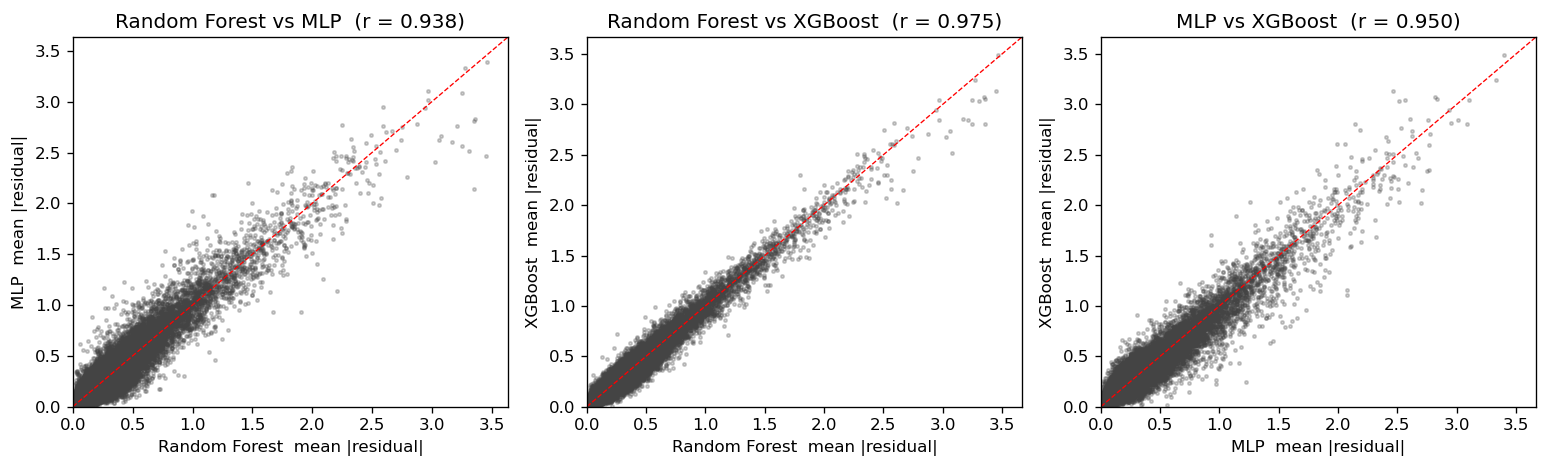

In [17]:
# Pairwise correlation of per-MOF mean abs_error between models, on the shared
# universe of MOFs that appear in all three test sets.
if len(preds_by_model) == 3:
    mean_err = {}
    for m, df in preds_by_model.items():
        mean_err[MODEL_LABEL[m]] = df.groupby('name')['abs_error'].mean()
    err_df = pd.DataFrame(mean_err).dropna()
    print(f'Shared MOFs across all three models: {len(err_df):,}')
    print('\nPearson correlation of mean |residual| between models:')
    print(err_df.corr(method='pearson').round(3))
    print('\nSpearman correlation:')
    print(err_df.corr(method='spearman').round(3))

    # Scatter
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    pairs = [('Random Forest', 'MLP'), ('Random Forest', 'XGBoost'), ('MLP', 'XGBoost')]
    for ax, (a, b) in zip(axes, pairs):
        ax.scatter(err_df[a], err_df[b], s=4, alpha=0.25, color='#444')
        lim = max(err_df[a].max(), err_df[b].max()) * 1.05
        ax.plot([0, lim], [0, lim], color='red', lw=0.8, ls='--')
        ax.set_xlabel(f'{a}  mean |residual|')
        ax.set_ylabel(f'{b}  mean |residual|')
        r = err_df[a].corr(err_df[b])
        ax.set_title(f'{a} vs {b}  (r = {r:.3f})')
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    plt.tight_layout()
    plt.savefig(RESULTS / 'residual_correlation.png', bbox_inches='tight')
    plt.show()
else:
    print('Need all three parquets for residual correlation.')

In [18]:
CIF_DIR = ROOT / 'data' / 'cif_structures'

if len(preds_by_model) == 3:
    THRESH = 0.5
    sets = {m: set(ps[ps >= THRESH].index) for m, ps in persist_by_model.items()}
    shared = sorted(sets['rf'] & sets['mlp'] & sets['xgb'])

    # Per-model mean abs_error across the 9 conditions for the shared MOFs.
    err_cols = {}
    for m, df in preds_by_model.items():
        err_cols[f'mae_{m}'] = (
            df[df['name'].isin(shared)].groupby('name')['abs_error'].mean()
        )
    err_tbl = pd.DataFrame(err_cols)
    err_tbl['mae_total'] = err_tbl.sum(axis=1)

    # y_true is invariant across splits/feature sets, so take it from any one row per MOF.
    y_true_lookup = (
        preds_by_model['rf']
        .drop_duplicates('name')
        .set_index('name')['y_true']
        .rename('y_true_co2_mol_kg_0p1bar')
    )

    # Pull structural metadata from the master parquet.
    GEO_COLS = ['pld', 'lcd', 'surface_area_m2g', 'void_fraction', 'density_g_cm3']
    meta = pd.read_parquet(
        ROOT / 'data' / 'merged' / 'hmof_merged.parquet',
        columns=['name', 'topology', 'metal_node'] + GEO_COLS,
    ).set_index('name')

    browse = (
        err_tbl
        .join(y_true_lookup)
        .join(meta)
        .sort_values('mae_total', ascending=False)
    )
    browse['cif_path'] = browse.index.to_series().apply(
        lambda n: str((CIF_DIR / f'{n}.cif').relative_to(ROOT))
        if (CIF_DIR / f'{n}.cif').exists() else ''
    )
    browse['cif_exists'] = browse['cif_path'] != ''

    out_csv = RESULTS / 'shared_outliers_browsing_table.csv'
    browse.to_csv(out_csv)
    print(f'Saved browsing table for {len(browse):,} shared persistent outliers '
          f'({browse["cif_exists"].sum():,} have CIFs) to:')
    print(f'  {out_csv.relative_to(ROOT)}')

    # Show the worst 15 with the columns most useful for picking which ones to open.
    preview_cols = ['mae_total', 'mae_rf', 'mae_mlp', 'mae_xgb',
                    'y_true_co2_mol_kg_0p1bar', 'topology', 'metal_node',
                    'pld', 'lcd', 'surface_area_m2g', 'void_fraction', 'density_g_cm3',
                    'cif_path']
    print('\nTop 15 shared-persistent outliers by total mean error:')
    print(browse[preview_cols].head(15).round(3).to_string())
else:
    print('Need all three parquets for the browsing table.')

Saved browsing table for 2,070 shared persistent outliers (2,070 have CIFs) to:
  results/model-comparison-outliers/shared_outliers_browsing_table.csv

Top 15 shared-persistent outliers by total mean error:
              mae_total  mae_rf  mae_mlp  mae_xgb  y_true_co2_mol_kg_0p1bar topology metal_node   pld   lcd  surface_area_m2g  void_fraction  density_g_cm3                              cif_path
name                                                                                                                                                                                             
hMOF-5014425     10.352   3.463    3.395    3.494                     4.990      pcu         Zn  3.75  5.75             752.5          0.451          1.141  data/cif_structures/hMOF-5014425.cif
hMOF-5015243      9.840   3.274    3.329    3.238                     5.034      pcu         Zn  3.25  6.25            1205.2          0.548          1.139  data/cif_structures/hMOF-5015243.cif
hMOF-35393       

In [19]:
import shutil

# How many of the worst-error shared outliers to copy.  Bump if you want more.
TOP_N = 20

if len(preds_by_model) == 3:
    cif_out_dir = RESULTS / 'cifs'
    cif_out_dir.mkdir(exist_ok=True)

    # Wipe any previous copies so re-running doesn't leave stale files.
    for old in cif_out_dir.glob('*.cif'):
        old.unlink()

    top = browse[browse['cif_exists']].head(TOP_N)
    copied = []
    for rank, (name, row) in enumerate(top.iterrows(), start=1):
        src = CIF_DIR / f'{name}.cif'
        # Prefix with rank so they sort by severity in the file browser.
        dst = cif_out_dir / f'{rank:02d}__{name}__mae{row["mae_total"]:.2f}.cif'
        shutil.copyfile(src, dst)
        copied.append(dst.name)

    print(f'Copied top-{len(copied)} shared persistent outliers to: '
          f'{cif_out_dir.relative_to(ROOT)}/')
    for f in copied:
        print(f'  {f}')
    print(f'\nOpen the folder in Finder and double-click any .cif to launch in Avogadro:')
    print(f'  open "{cif_out_dir}"')
else:
    print('Need all three parquets to copy CIFs.')

Copied top-20 shared persistent outliers to: results/model-comparison-outliers/cifs/
  01__hMOF-5014425__mae10.35.cif
  02__hMOF-5015243__mae9.84.cif
  03__hMOF-35393__mae9.24.cif
  04__hMOF-5073738__mae9.24.cif
  05__hMOF-5074862__mae9.14.cif
  06__hMOF-5819__mae9.11.cif
  07__hMOF-34708__mae9.05.cif
  08__hMOF-35297__mae8.86.cif
  09__hMOF-35295__mae8.85.cif
  10__hMOF-2279__mae8.83.cif
  11__hMOF-24029__mae8.82.cif
  12__hMOF-37152__mae8.81.cif
  13__hMOF-34229__mae8.63.cif
  14__hMOF-5068170__mae8.42.cif
  15__hMOF-36862__mae8.36.cif
  16__hMOF-6516__mae8.35.cif
  17__hMOF-5058330__mae8.30.cif
  18__hMOF-5075574__mae8.26.cif
  19__hMOF-5082908__mae8.11.cif
  20__hMOF-36540__mae8.05.cif

Open the folder in Finder and double-click any .cif to launch in Avogadro:
  open "/Users/hannah/Desktop/ethz/Semester6/dc-mof-project/results/model-comparison-outliers/cifs"


## Poster figure - descriptor-type mix (normalised within model)

Same data as the descriptor-category bars above, but only the **normalised** view, restyled
for the poster: new palette (RF navy / XGB teal / MLP purple), model order RF -> XGB -> MLP,
no outlines.

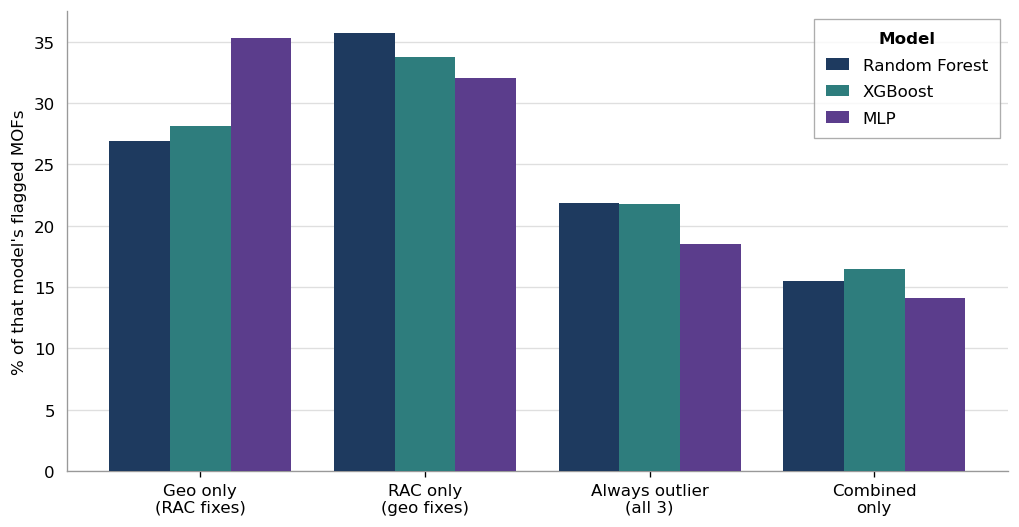

In [20]:
# Poster palette (overrides MODEL_COLOR for this cell only)
POSTER_MODEL_COLOR = {'rf': '#1E3A5F', 'mlp': '#5B3D8C', 'xgb': '#2E7D7D'}
POSTER_MODEL_FULL  = {'rf': 'Random Forest', 'mlp': 'MLP', 'xgb': 'XGBoost'}
MODELS_ORDER       = ['rf', 'xgb', 'mlp']

# Two-line labels so they stay horizontal without overlapping
cats        = ['Geo only (RAC fixes)', 'RAC only (geo fixes)',
               'Always outlier (all 3)', 'Combined only']
cat_labels  = ['Geo only\n(RAC fixes)', 'RAC only\n(geo fixes)',
               'Always outlier\n(all 3)', 'Combined\nonly']
x = np.arange(len(cats)); w = 0.27

fig, ax = plt.subplots(figsize=(8.6, 4.5))

for i, m in enumerate(MODELS_ORDER):
    total = sum(DESCRIPTOR[m].values())
    vals = [DESCRIPTOR[m][c] / total * 100 for c in cats]
    ax.bar(x + (i - 1) * w, vals, width=w,
           color=POSTER_MODEL_COLOR[m], edgecolor='none', linewidth=0,
           label=POSTER_MODEL_FULL[m], zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(cat_labels, rotation=0, ha='center')
ax.set_ylabel("% of that model's flagged MOFs")

leg = ax.legend(loc='upper right', title='Model',
                handlelength=1.4, borderpad=0.7, labelspacing=0.7,
                frameon=True, fancybox=False, edgecolor='#999',
                facecolor='white')
leg.get_title().set_fontweight('semibold')
leg.get_frame().set_linewidth(0.8)

ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig(RESULTS / 'descriptor_category_comparison_poster.png',
            dpi=300, bbox_inches='tight')
plt.show()

## Notes for follow-up

- All summary tables (`RMSE`, `OUTLIER_PCT`, `PERSISTENCE`, `DESCRIPTOR`) are at the top of the
  notebook and easy to refresh if any per-model notebook is rerun with different hyperparameters.
- The per-MOF section is only as good as the parquets feeding it: regenerate them from each
  per-model notebook with the *same* outlier threshold definition (2 sigma of `abs_error`
  computed per condition).
- Structural characterisation (topology / metal-node / geometric features) is done within each
  per-model notebook against the same merged metadata file - if you want it overlaid across
  models, the `shared_persistent_outliers.parquet` saved above is the right starting point.